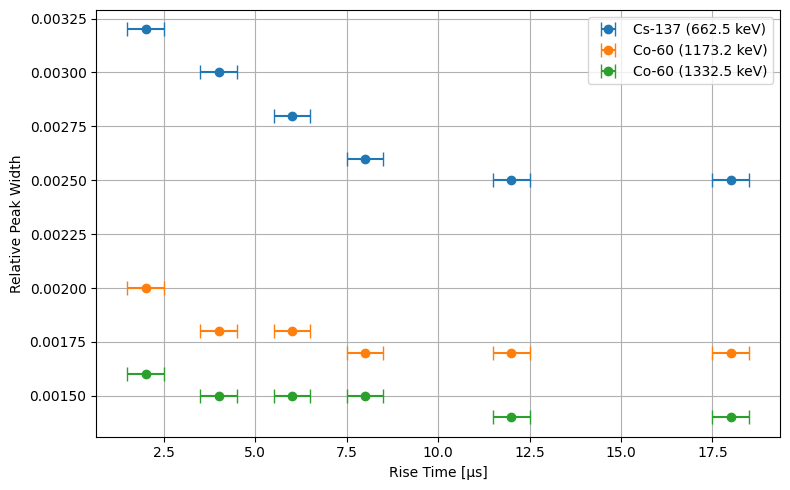

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
rise_times = np.array([2, 4, 6, 8, 12, 18], dtype=float)  # X-axis: Rise Times in µs
cs_peak = np.array([0.0032, 0.003, 0.0028, 0.0026, 0.0025, 0.0025])  # Cs-137 peak
co_peak_1173 = np.array([0.0020, 0.0018, 0.0018, 0.0017, 0.0017, 0.0017])  # Co-60 (1173.2 keV)
co_peak_1332 = np.array([0.0016, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014])  # Co-60 (1332.5 keV)

# Errors (arbitrary for this demonstration)
errors_x = np.full_like(rise_times, 0.5)  # X-axis errors (±1 µs)

# Create the plot
plt.figure(figsize=(8, 5))
plt.errorbar(rise_times, cs_peak, xerr=errors_x, fmt='o', label='Cs-137 (662.5 keV)', capsize=5)
plt.errorbar(rise_times, co_peak_1173, xerr=errors_x, fmt='o', label='Co-60 (1173.2 keV)', capsize=5)
plt.errorbar(rise_times, co_peak_1332, xerr=errors_x, fmt='o', label='Co-60 (1332.5 keV)', capsize=5)

# Labeling
plt.xlabel('Rise Time [µs]')
plt.ylabel('Relative Peak Width')
# plt.title('Relative Peak Width versus Rise Time [µs]')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.savefig('relative_peak_width_vs_rise_time.png', dpi=1000)
plt.show()


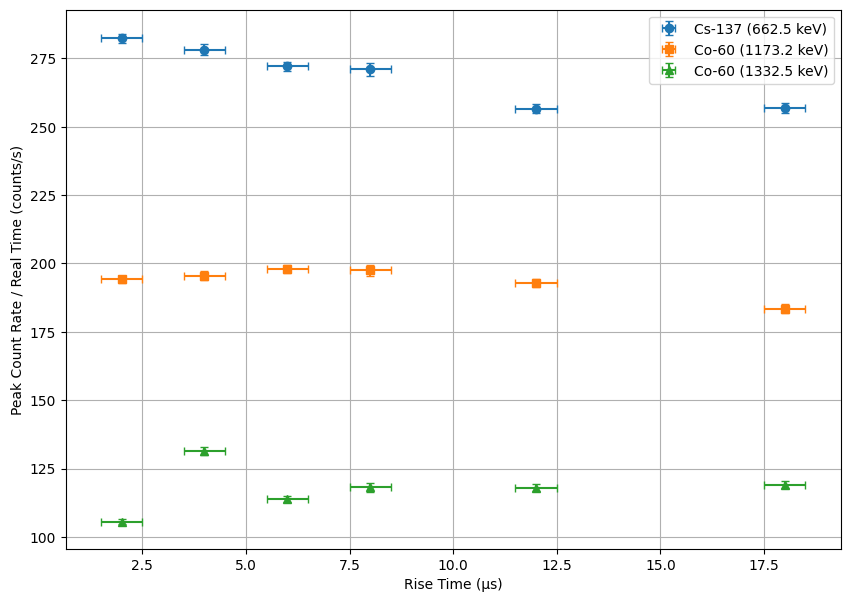

In [25]:
import numpy as np

# Function to calculate propagated uncertainty for y = Peak Count / Real Time
def calculate_y_uncertainty(peak, real_time, sigma_real_time=0):
    sigma_peak = np.sqrt(peak)  # Uncertainty in peak count (counting statistics)
    y = peak / real_time  # y-value
    # Propagate uncertainty
    sigma_y = y * np.sqrt((sigma_peak / peak) ** 2 + (sigma_real_time / real_time) ** 2)
    return sigma_y

# Peak 1 (already plotted)
peak1_data = {
    "Rise Time (µs)": [2, 4, 6, 8, 12, 18],
    "Peak Count Rate / Real Time (counts/s)": [
        34668 / 122.8,
        21394 / 76.9,
        26509 / 97.4,
        13010 / 48,
        21503 / 83.8,
        19412 / 75.6,
    ],
}

# Peak 2 (example values for illustration)
peak2_data = {
    "Rise Time (µs)": [2, 4, 6, 8, 12, 18],
    "Peak Count Rate / Real Time (counts/s)": [
        23456 / 120.8,
        15432 / 78.9,
        19876 / 100.4,
        9876 / 50,
        16543 / 85.8,
        14421 / 78.6,
    ],
}

# Peak 3 (example values for illustration)
peak3_data = {
    "Rise Time (µs)": [2, 4, 6, 8, 12, 18],
    "Peak Count Rate / Real Time (counts/s)": [
        12543 / 118.8,
        9843 / 74.9,
        10987 / 96.4,
        5432 / 46,
        9654 / 81.8,
        8765 / 73.6,
    ],
}




# Add uncertainties for Peak 1
peak1_y_errors = [
    calculate_y_uncertainty(34668, 122.8),
    calculate_y_uncertainty(21394, 76.9),
    calculate_y_uncertainty(26509, 97.4),
    calculate_y_uncertainty(13010, 48),
    calculate_y_uncertainty(21503, 83.8),
    calculate_y_uncertainty(19412, 75.6),
]

# Add uncertainties for Peak 2 (example values)
peak2_y_errors = [
    calculate_y_uncertainty(23456, 120.8),
    calculate_y_uncertainty(15432, 78.9),
    calculate_y_uncertainty(19876, 100.4),
    calculate_y_uncertainty(9876, 50),
    calculate_y_uncertainty(16543, 85.8),
    calculate_y_uncertainty(14421, 78.6),
]

# Add uncertainties for Peak 3 (example values)
peak3_y_errors = [
    calculate_y_uncertainty(12543, 118.8),
    calculate_y_uncertainty(9843, 74.9),
    calculate_y_uncertainty(10987, 96.4),
    calculate_y_uncertainty(5432, 46),
    calculate_y_uncertainty(9654, 81.8),
    calculate_y_uncertainty(8765, 73.6),
]

# Create the plot with both x and y error bars for all three peaks
plt.figure(figsize=(10, 7))
plt.errorbar(
    peak1_data["Rise Time (µs)"],
    peak1_data["Peak Count Rate / Real Time (counts/s)"],
    xerr=0.5,
    yerr=peak1_y_errors,
    fmt="o",
    label="Cs-137 (662.5 keV)",
    capsize=3,
)
plt.errorbar(
    peak2_data["Rise Time (µs)"],
    peak2_data["Peak Count Rate / Real Time (counts/s)"],
    xerr=0.5,
    yerr=peak2_y_errors,
    fmt="s",
    label="Co-60 (1173.2 keV)",
    capsize=3,
)
plt.errorbar(
    peak3_data["Rise Time (µs)"],
    peak3_data["Peak Count Rate / Real Time (counts/s)"],
    xerr=0.5,
    yerr=peak3_y_errors,
    fmt="^",
    label="Co-60 (1332.5 keV)",
    capsize=3,
)

# Labeling the axes and setting the title
plt.xlabel("Rise Time (µs)")
plt.ylabel("Peak Count Rate / Real Time (counts/s)")
# plt.title("Peak Count Rate per Real Time vs Rise Time with Error Bars")
plt.legend()
plt.grid(True)
plt.savefig('peak_count_rate_vs_rise_time_with_error_bars.png', dpi=1000)
plt.show()


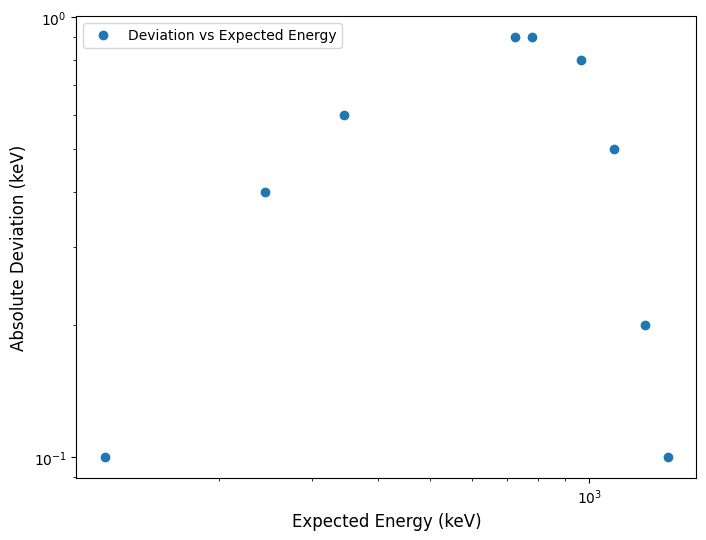

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Data
expected_energy = np.array([121.8, 244.7, 344.3, 723.4, 778.9, 964.0, 1112.1, 1274.5, 1408.0])
deviation = np.array([0.1, 0.4, 0.6, 0.9, 0.9, 0.8, 0.5, 0.2, -0.1])

# Ensure deviations are absolute values for log-log plot
absolute_deviation = np.abs(deviation)

# Plot as a scatter plot
plt.figure(figsize=(8, 6))
plt.loglog(expected_energy, absolute_deviation, marker='o', linestyle='None', label='Deviation vs Expected Energy')

# Labels and title
plt.xlabel('Expected Energy (keV)', fontsize=12)
plt.ylabel('Absolute Deviation (keV)', fontsize=12)
# plt.title('Log-Log Scatter Plot of Deviation vs Expected Energy', fontsize=14)
plt.legend()
plt.savefig('log_log_scatter_plot_deviation_vs_expected_energy.png', dpi=1000)
plt.show()

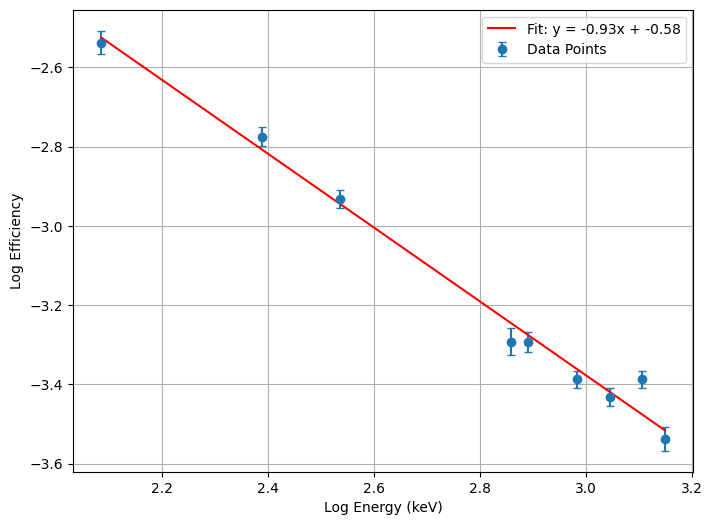

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the table
data = {
    "Isotope": ["Eu-152", "Eu-152", "Eu-152", "Eu-154", "Eu-152", "Eu-152", "Eu-152", "Eu-154", "Eu-152"],
    "E_gamma_keV": [121.8, 244.7, 344.3, 723.4, 778.9, 964.0, 1112.1, 1274.5, 1408.0],
    "Intrinsic_Efficiency": [0.0029, 0.00168, 0.00117, 0.00051, 0.00051, 0.00041, 0.00037, 0.00041, 0.00029],
    "Intrinsic_Efficiency_Error": [0.0002, 0.00009, 0.00006, 0.00004, 0.00003, 0.00002, 0.00002, 0.00002, 0.00002],
}

# Convert to a DataFrame for easier manipulation
df = pd.DataFrame(data)

# Perform log transformation of energy and efficiency
df["Log_Energy"] = np.log10(df["E_gamma_keV"])
df["Log_Efficiency"] = np.log10(df["Intrinsic_Efficiency"])
df["Log_Efficiency_Error"] = df["Intrinsic_Efficiency_Error"] / df["Intrinsic_Efficiency"] / np.log(10)

# Fit a linear model to the log-log data
fit_params = np.polyfit(df["Log_Energy"], df["Log_Efficiency"], 1)
fit_line = np.poly1d(fit_params)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.errorbar(
    df["Log_Energy"],
    df["Log_Efficiency"],
    yerr=df["Log_Efficiency_Error"],
    fmt='o',
    label="Data Points",
    capsize=3
)
plt.plot(df["Log_Energy"], fit_line(df["Log_Energy"]), 'r-', label=f"Fit: y = {fit_params[0]:.2f}x + {fit_params[1]:.2f}")

# Add labels and legend
plt.xlabel("Log Energy (keV)")
plt.ylabel("Log Efficiency")
# plt.title("Log of Emission Energy vs Log of Efficiency")
plt.legend()
plt.grid()

# Show the plot
plt.savefig('log_emission_energy_vs_log_efficiency.png', dpi=1000)
plt.show()


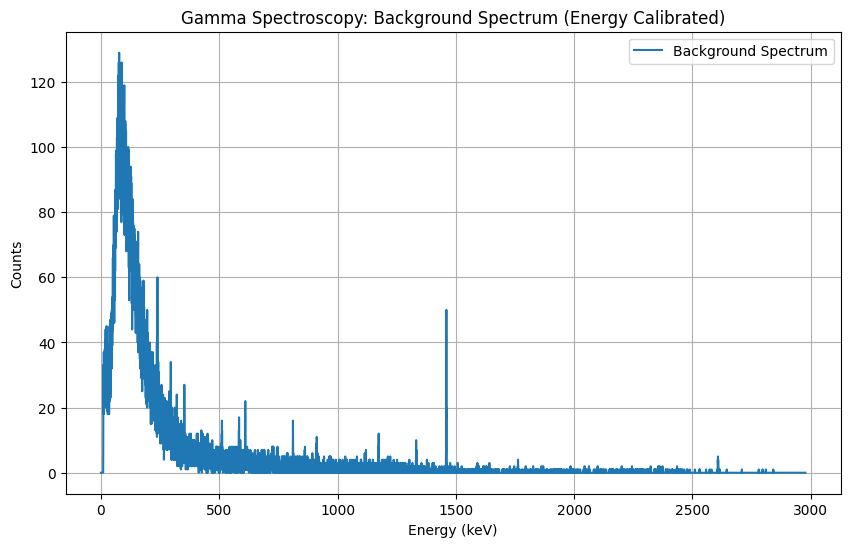

In [4]:
import matplotlib.pyplot as plt

# Define the energy calibration equation
def channel_to_energy(channel):
    return -0.0950 + 0.199753 * channel - 8.17227e-8 * channel**2

# Function to process and plot the spectrum
def process_spectrum(spectrum_file, max_channel=15000):
    # Read the spectrum file
    with open(spectrum_file, 'r') as file:
        data = file.readlines()

    # Locate the spectral data
    spectral_data = []
    data_section = False

    for line in data:
        if "$DATA:" in line:
            data_section = True
            continue
        if data_section and line.strip().isdigit():
            spectral_data.append(int(line.strip()))

    # Limit the data to the specified maximum channel
    adjusted_data = spectral_data[:max_channel]

    # Convert channels to energies
    channels = range(len(adjusted_data))
    energies = [channel_to_energy(ch) for ch in channels]

    # Plot the spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(energies, adjusted_data, label='Background Spectrum')
    plt.xlabel('Energy (keV)')
    plt.ylabel('Counts')
    plt.title('Gamma Spectroscopy: Background Spectrum (Energy Calibrated)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Usage
spectrum_file = 'background_spectrum.Spe'  # Replace with your file path
process_spectrum(spectrum_file)


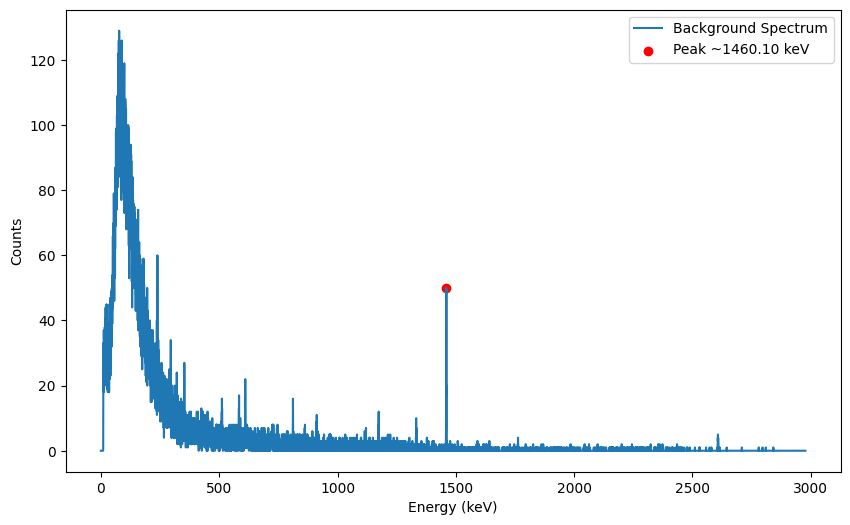

Identified peak energy: 1460.10 keV


In [7]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Define the energy calibration equation
def channel_to_energy(channel):
    return -0.0950 + 0.199753 * channel - 8.17227e-8 * channel**2

# Function to process and plot the spectrum
def process_spectrum(spectrum_file, max_channel=15000, target_energy=1500, peak_height=50):
    # Read the spectrum file
    with open(spectrum_file, 'r') as file:
        data = file.readlines()

    # Locate the spectral data
    spectral_data = []
    data_section = False

    for line in data:
        if "$DATA:" in line:
            data_section = True
            continue
        if data_section and line.strip().isdigit():
            spectral_data.append(int(line.strip()))

    # Limit the data to the specified maximum channel
    adjusted_data = spectral_data[:max_channel]

    # Convert channels to energies
    channels = range(len(adjusted_data))
    energies = [channel_to_energy(ch) for ch in channels]

    # Detect peaks in the spectrum
    peaks, _ = find_peaks(adjusted_data, height=peak_height)
    peak_energies = [channel_to_energy(ch) for ch in peaks]

    # Identify the closest peak to the target energy
    energy_range_min = target_energy - 100  # keV
    energy_range_max = target_energy + 100  # keV
    peaks_in_range = [
        i for i, energy in enumerate(peak_energies)
        if energy_range_min <= energy <= energy_range_max
    ]

    closest_energy = None
    closest_channel = None
    if peaks_in_range:
        closest_peak_index = min(peaks_in_range, key=lambda i: abs(peak_energies[i] - target_energy))
        closest_energy = peak_energies[closest_peak_index]
        closest_channel = peaks[closest_peak_index]

    # Plot the spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(energies, adjusted_data, label='Background Spectrum')
    if closest_energy and closest_channel:
        plt.scatter([closest_energy], [adjusted_data[closest_channel]], color='red', label=f'Peak ~{closest_energy:.2f} keV')
    plt.xlabel('Energy (keV)')
    plt.ylabel('Counts')
    # plt.title('Gamma Spectroscopy: Background Spectrum (Energy Calibrated)')
    plt.legend()
    # plt.grid(True)
    plt.savefig('gamma_spectroscopy_background_spectrum.png', dpi=1000)
    plt.show()

    # Return identified peak energy
    return closest_energy

# Usage
spectrum_file = 'background_spectrum.Spe'  # Replace with your file path
identified_peak_energy = process_spectrum(spectrum_file)
print(f"Identified peak energy: {identified_peak_energy:.2f} keV" if identified_peak_energy else "No peak identified.")


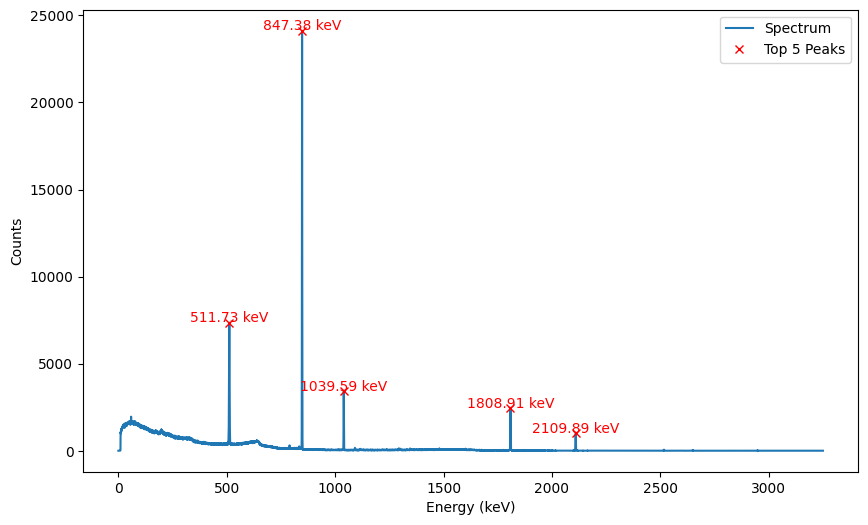

Adjusted Top 5 Peaks (Energy, Counts):
Energy 2109.89 keV: 994 counts
Energy 1808.91 keV: 2448 counts
Energy 1039.59 keV: 3419 counts
Energy 511.73 keV: 7356 counts
Energy 847.38 keV: 24119 counts


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load spectrum data from file
def load_spectrum(file_path):
    with open(file_path, 'r') as file:
        data = file.readlines()

    # Locate and parse the spectrum data section
    data_start_index = data.index('$DATA:\n') + 2
    spectrum_data = []
    for line in data[data_start_index:]:
        try:
            spectrum_data.append(int(line.strip()))
        except ValueError:
            break
    return np.array(spectrum_data)

# Define the energy calibration equation
def channel_to_energy(channel):
    return -0.0950 + 0.199753 * channel - 8.17227e-8 * channel**2

# Process and plot the top 5 adjusted peaks
def plot_spectrum_with_energy(spectrum):
    # Find initial prominent peaks
    prominent_peaks, _ = find_peaks(spectrum, prominence=500, distance=50)

    # Remove unwanted peak at channel 294
    filtered_peaks = prominent_peaks[prominent_peaks != 294]

    # Ensure inclusion of the peak around channel 11000
    peak_around_11000 = np.argmax(spectrum[10000:12000]) + 10000
    filtered_peaks = np.append(filtered_peaks, peak_around_11000)
    filtered_peaks = np.unique(filtered_peaks)
    filtered_heights = spectrum[filtered_peaks]

    # Select top 5 peaks
    sorted_indices = np.argsort(filtered_heights)[-5:]
    top_5_peaks = filtered_peaks[sorted_indices]
    top_5_heights = filtered_heights[sorted_indices]

    # Convert channels to energy
    energy = channel_to_energy(np.arange(len(spectrum)))
    top_5_energies = channel_to_energy(top_5_peaks)

    # Plot the spectrum with the x-axis in energy (keV)
    plt.figure(figsize=(10, 6))
    plt.plot(energy, spectrum, label="Spectrum")
    plt.plot(top_5_energies, top_5_heights, "x", color="red", label="Top 5 Peaks")
    for energy_value, height in zip(top_5_energies, top_5_heights):
        plt.text(energy_value, height + 50, f"{energy_value:.2f} keV", ha='center', color='red')
    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts")
    # plt.title("Spectrum Data with Top 5 Peaks (Energy Calibration)")
    plt.legend()
    # plt.grid()
    plt.savefig('spectrum_data_with_top_5_peaks.png', dpi=1000)
    plt.show()

    # Output the peak details
    return list(zip(top_5_energies, top_5_heights))

# Main script execution
spectrum_file_path = "firstruncoin.Spe"  # Replace with the spectrum file path
spectrum = load_spectrum(spectrum_file_path)
peak_details = plot_spectrum_with_energy(spectrum)

# Print peak details
print("Adjusted Top 5 Peaks (Energy, Counts):")
for energy, count in peak_details:
    print(f"Energy {energy:.2f} keV: {count} counts")


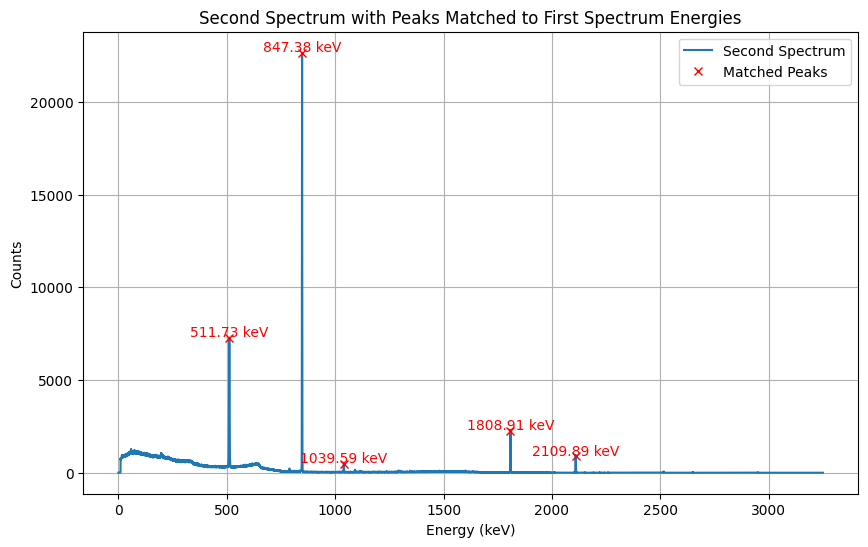

Matched Peaks (Energy, Counts):
Energy 511.73 keV: 7288 counts
Energy 847.38 keV: 22646 counts
Energy 1039.59 keV: 489 counts
Energy 1808.91 keV: 2270 counts
Energy 2109.89 keV: 910 counts


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Load spectrum data from file
def load_spectrum(file_path):
    with open(file_path, 'r') as file:
        data = file.readlines()

    # Locate and parse the spectrum data section
    data_start_index = data.index('$DATA:\n') + 2
    spectrum_data = []
    for line in data[data_start_index:]:
        try:
            spectrum_data.append(int(line.strip()))
        except ValueError:
            break
    return np.array(spectrum_data)

# Define the energy calibration equation
def channel_to_energy(channel):
    return -0.0950 + 0.199753 * channel - 8.17227e-8 * channel**2

# Match peaks in the second spectrum to the reference energies
def match_peaks_to_reference(spectrum, reference_energies):
    # Find the closest matching channels to the reference energies
    closest_channels = [
        np.abs(channel_to_energy(np.arange(len(spectrum))) - energy).argmin()
        for energy in reference_energies
    ]
    closest_counts = spectrum[closest_channels]
    closest_energies = channel_to_energy(np.array(closest_channels))
    return closest_energies, closest_counts

# Plot the spectrum with matched peaks
def plot_matched_peaks(spectrum, matched_energies, matched_counts, reference_energies):
    energy = channel_to_energy(np.arange(len(spectrum)))
    plt.figure(figsize=(10, 6))
    plt.plot(energy, spectrum, label="Second Spectrum")
    plt.plot(matched_energies, matched_counts, "x", color="red", label="Matched Peaks")
    for energy_value, count in zip(matched_energies, matched_counts):
        plt.text(energy_value, count + 50, f"{energy_value:.2f} keV", ha='center', color='red')
    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts")
    plt.title("Second Spectrum with Peaks Matched to First Spectrum Energies")
    plt.legend()
    plt.grid()
    plt.show()

# Main script execution
second_spectrum_file_path = "secondruncoin.Spe"  # Replace with the second spectrum file path
reference_energies = [511.73, 847.38, 1039.59, 1808.91, 2109.89]  # Reference energies from the first spectrum

# Process the second spectrum
second_spectrum = load_spectrum(second_spectrum_file_path)
matched_energies, matched_counts = match_peaks_to_reference(second_spectrum, reference_energies)

# Plot the matched peaks
plot_matched_peaks(second_spectrum, matched_energies, matched_counts, reference_energies)

# Output the matched peak details
print("Matched Peaks (Energy, Counts):")
for energy, count in zip(matched_energies, matched_counts):
    print(f"Energy {energy:.2f} keV: {count} counts")


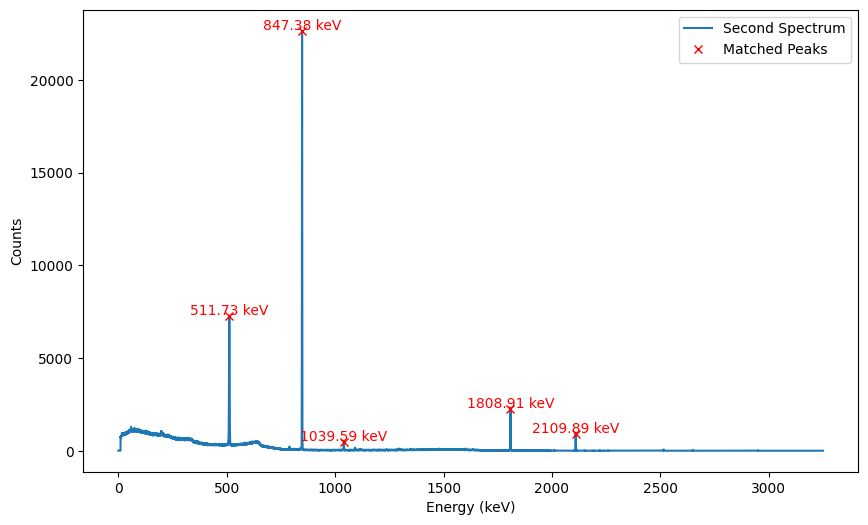

Matched Peaks (Energy, Counts):
Energy 511.73 keV: 7288 counts
Energy 847.38 keV: 22646 counts
Energy 1039.59 keV: 489 counts
Energy 1808.91 keV: 2270 counts
Energy 2109.89 keV: 910 counts


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Load spectrum data from file
def load_spectrum(file_path):
    with open(file_path, 'r') as file:
        data = file.readlines()

    # Locate and parse the spectrum data section
    data_start_index = data.index('$DATA:\n') + 2
    spectrum_data = []
    for line in data[data_start_index:]:
        try:
            spectrum_data.append(int(line.strip()))
        except ValueError:
            break
    return np.array(spectrum_data)

# Define the energy calibration equation
def channel_to_energy(channel):
    return -0.0950 + 0.199753 * channel - 8.17227e-8 * channel**2

# Match peaks in the second spectrum to the reference energies
def match_peaks_to_reference(spectrum, reference_energies):
    # Find the closest matching channels to the reference energies
    closest_channels = [
        np.abs(channel_to_energy(np.arange(len(spectrum))) - energy).argmin()
        for energy in reference_energies
    ]
    closest_counts = spectrum[closest_channels]
    closest_energies = channel_to_energy(np.array(closest_channels))
    return closest_energies, closest_counts

# Plot the spectrum with matched peaks
def plot_matched_peaks(spectrum, matched_energies, matched_counts, reference_energies):
    energy = channel_to_energy(np.arange(len(spectrum)))
    plt.figure(figsize=(10, 6))
    plt.plot(energy, spectrum, label="Second Spectrum")
    plt.plot(matched_energies, matched_counts, "x", color="red", label="Matched Peaks")
    for energy_value, count in zip(matched_energies, matched_counts):
        plt.text(energy_value, count + 50, f"{energy_value:.2f} keV", ha='center', color='red')
    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts")
    # plt.title("Second Spectrum with Peaks Matched to First Spectrum Energies")
    plt.legend()
    # plt.grid()
    plt.savefig('second_spectrum_with_matched_peaks.png', dpi=1000)
    plt.show()

# Main script execution
second_spectrum_file_path = "secondruncoin.Spe"  # Replace with the second spectrum file path
reference_energies = [511.73, 847.38, 1039.59, 1808.91, 2109.89]  # Reference energies from the first spectrum

# Process the second spectrum
second_spectrum = load_spectrum(second_spectrum_file_path)
matched_energies, matched_counts = match_peaks_to_reference(second_spectrum, reference_energies)

# Plot the matched peaks
plot_matched_peaks(second_spectrum, matched_energies, matched_counts, reference_energies)

# Output the matched peak details
print("Matched Peaks (Energy, Counts):")
for energy, count in zip(matched_energies, matched_counts):
    print(f"Energy {energy:.2f} keV: {count} counts")
